In [6]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
a = os.getcwd()
print(a)

g:\Mi unidad\02 PROYECTOS\Portfolio\box\Jupyter


In [8]:
"""Conectar a la base de datos
try:
    ruta_db = r'/content/drive/MyDrive/SISTEMAS/BASE DE DATOS/SQLite/sakila.db'

    if os.path.exists(ruta_db):
      conn = sqlite3.connect(ruta_db)
      print("Conexión exitosa a la base de datos.")

    else:
      print(f"No se encontró la base de datos en: {ruta_db}")

except Exception as e:
  print(f"Error al conectar o crear la tabla: {e}")"""

# Crear y conectar a una DB SQLite3

db = r'G:\Mi unidad\02 PROYECTOS\Portfolio\box\Jupyter\Ciudad.db'

conn = sqlite3.connect(db)
query = conn.cursor()
print("Conexión exitosa a la base de datos.")

Conexión exitosa a la base de datos.


In [9]:
# CREAR Tabla de datos
conn.execute('''CREATE TABLE IF NOT EXISTS cities (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                nombre TEXT NOT NULL,
                edad INTEGER NOT NULL,
                ciudad TEXT NOT NULL);''')

In [10]:
# Insertar datos a tabla
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('Juan', 25, 'Medellín')")
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('María', 10, 'Montevideo')")
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('Pedro', 58, 'Lima')")

In [11]:
# Consulta 1: Obtener todos los usuarios
query1 = "SELECT * FROM cities"
result1 = conn.execute(query1).fetchall()
print("Consulta 1 - Todos los usuarios:")
for row in result1:
    print(row)

Consulta 1 - Todos los usuarios:
(1, 'Juan', 25, 'Medellín')
(2, 'María', 10, 'Montevideo')
(3, 'Pedro', 58, 'Lima')


In [12]:
# Consulta 2: Obtener usuarios con edad mayor a 25
query2 = "SELECT nombre, edad FROM cities WHERE edad > 25"
result2 = conn.execute(query2).fetchall()
print("\nConsulta 2 - Usuarios con edad mayor a 25:")
for row in result2:
    print(row)


Consulta 2 - Usuarios con edad mayor a 25:
('Pedro', 58)


In [13]:
# Consulta 3: Obtener el total de usuarios por ciudad
query3 = "SELECT ciudad, COUNT(*) as total FROM cities GROUP BY ciudad"
result3 = conn.execute(query3).fetchall()
print("\nConsulta 3 - Total de usuarios por ciudad:")
for row in result3:
    print(row)


Consulta 3 - Total de usuarios por ciudad:
('Lima', 1)
('Medellín', 1)
('Montevideo', 1)


In [14]:
# Consultas con el DataFrame de Pandas
df_consulta_1 = pd.DataFrame(result1, columns=['id', 'nombre', 'edad', 'ciudad'])
df_consulta_2 = pd.DataFrame(result2, columns=['nombre', 'edad'])
df_consulta_3 = pd.DataFrame(result3, columns=['ciudad', 'total'])

# Visualizar la tabla resultante de la consulta 1
print("Tabla de usuarios:")
print(df_consulta_1)

# Visualizar el resultado de la consulta 2
print("\nUsuarios con edad mayor a 25:")
print(df_consulta_2)

# Visualizar el resultado de la consulta 3
print("\nTotal de usuarios por ciudad:")
print(df_consulta_3)

Tabla de usuarios:
   id nombre  edad      ciudad
0   1   Juan    25    Medellín
1   2  María    10  Montevideo
2   3  Pedro    58        Lima

Usuarios con edad mayor a 25:
  nombre  edad
0  Pedro    58

Total de usuarios por ciudad:
       ciudad  total
0        Lima      1
1    Medellín      1
2  Montevideo      1


In [15]:
# Análisis estadístico
edad_promedio = df_consulta_1['edad'].mean()
edad_maxima = df_consulta_1['edad'].max()
edad_minima = df_consulta_1['edad'].min()

# Imprimir los resultados del análisis estadístico
print("\nAnálisis estadístico:")
print(f"Edad promedio: {edad_promedio}")
print(f"Edad máxima: {edad_maxima}")
print(f"Edad mínima: {edad_minima}")


Análisis estadístico:
Edad promedio: 31.0
Edad máxima: 58
Edad mínima: 10


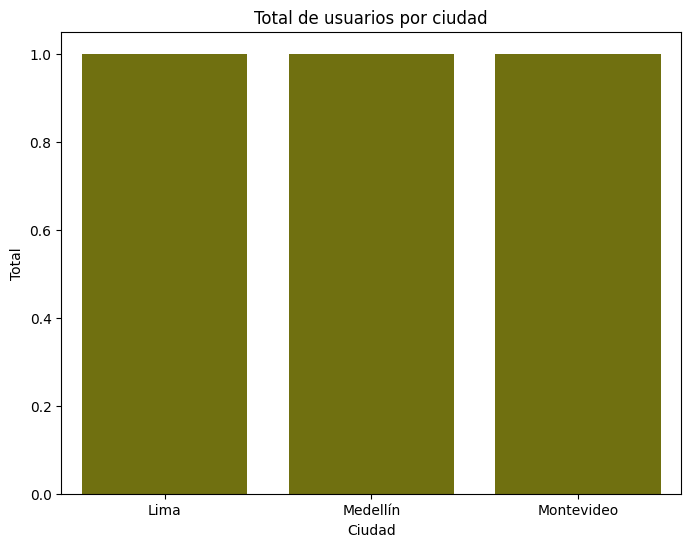

In [16]:
# Gráfico de barras del total de usuarios por ciudad
plt.figure(figsize=(8, 6))
sns.barplot(x='ciudad', y='total', color='olive', data=df_consulta_3)
plt.title('Total de usuarios por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Total')
plt.show()

In [17]:
# Insertar más datos de ejemplo en la tabla
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('Juan', 15, 'Montevideo')")
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('María', 50, 'Madrid')")
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('Pedro', 28, 'Lima')")
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('Laura', 12, 'Buenos Aires')")
conn.execute("INSERT INTO cities (nombre, edad, ciudad) VALUES ('Carlos', 45, 'Lima')")

In [19]:
# Consulta para obtener el total de usuarios por ciudad
query = "SELECT ciudad, COUNT(*) as total FROM cities GROUP BY ciudad"
result = conn.execute(query).fetchall()
df_result = pd.DataFrame(result, columns=['ciudad', 'total'])

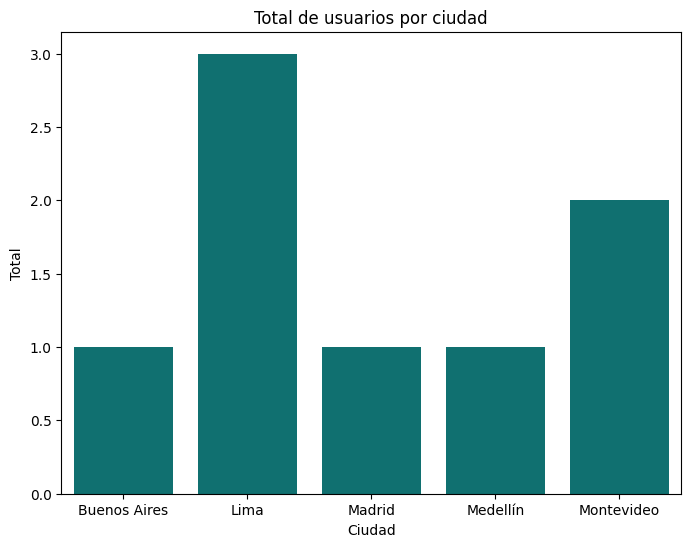

In [21]:
# Gráfico de barras del total de usuarios por ciudad
plt.figure(figsize=(8, 6))
sns.barplot(x='ciudad', y='total', color='teal', data=df_result)
plt.title('Total de usuarios por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Total')
plt.show()